                             NLGL (NONLINEAR GUIDANCE LAW) ERROR PERFORMANCE DASHBOARD                             

--- [A] NLGL STRAIGHT LINE PATH PERFORMANCE ---
Config       | Mean XTE   | Max XTE    | RMSE       | Final XTE   | Settle Time (5m)  | Settle Time (2m) 
-------------------------------------------------------------------------------------------------------------------
L = 10        |   18.377m |   84.156m |   31.715m |     0.003m | 25.90 s           | 26.60 s          
L = 30        |   14.039m |   84.156m |   29.771m |     0.000m | 15.45 s           | 17.20 s          
L = 50        |   13.781m |   84.156m |   29.756m |     0.000m | 13.05 s           | 16.00 s          
L = 120       |   20.536m |   84.156m |   33.255m |     0.382m | 25.20 s           | 32.30 s          

--- [B] NLGL LOITER CIRCULAR PATH PERFORMANCE ---
Config       | Mean XTE   | Max XTE    | RMSE       | Final XTE   | Settle Time (5m)  | Settle Time (2m) 
--------------------------------------------

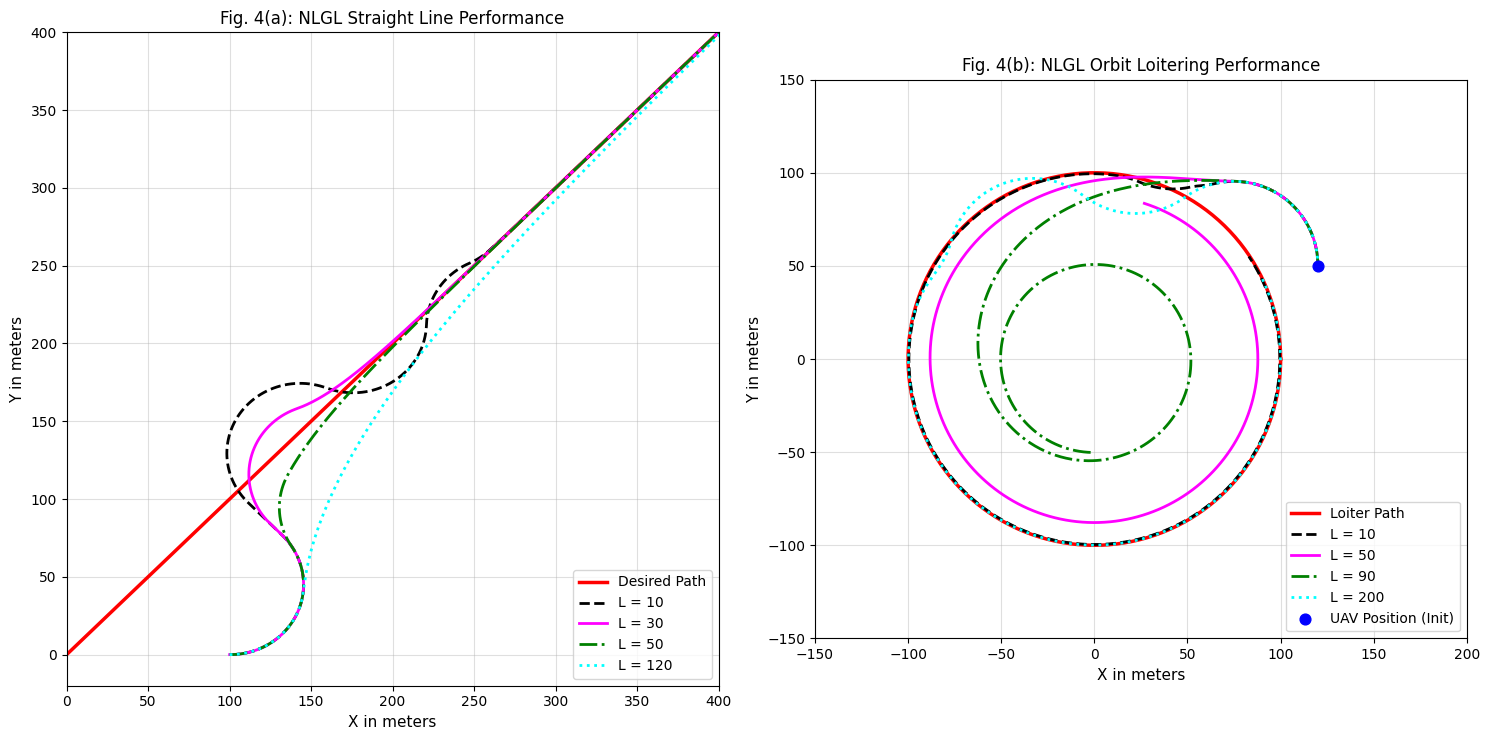

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# --- GLOBAL UAV CONFIGURATIONS (From Section II) ---
va = 15.0          # UAV airspeed (m/s)
rmin = 45.0        # Minimum turning radius (m)
wmax = va / rmin   # Max heading rate limit (rad/s)
dt = 0.05          # Time step (s)
sim_time = 45.0    # Total flight simulation time (s)
steps = int(sim_time / dt)

def wrap_angle(angle):
    """Ensures angles remain bounded within [-pi, pi]"""
    return (angle + np.pi) % (2 * np.pi) - np.pi

# =============================================================================
# 1. NLGL STRAIGHT-LINE SIMULATION (Replicating Fig. 4a)
# =============================================================================
def simulate_nlgl_line(L):
    # Initial state mimicking vehicle offset from the paper
    x, y = 100.0, 0.0
    psi = 0.0  # Initial heading parallel to x-axis

    # Path defined from W_i=(0,0) to W_{i+1}=(400,400) -> 45 degree line
    W_i = np.array([0.0, 0.0])
    W_ip1 = np.array([400.0, 400.0])

    path_vec = W_ip1 - W_i
    path_unit = path_vec / np.linalg.norm(path_vec)

    x_history, y_history = [x], [y]

    for _ in range(steps):
        p = np.array([x, y])
        w = p - W_i

        # Project UAV position onto the line segment to find the closest point
        proj = np.dot(w, path_unit)
        perp_dist = np.linalg.norm(w - proj * path_unit)

        # Compute look-ahead intersection point (VTP)
        if perp_dist < L:
            offset = np.sqrt(L**2 - perp_dist**2)
            xt, yt = W_i + (proj + offset) * path_unit
        else:
            # Fallback if the look-ahead circle cannot reach the line segment
            xt, yt = W_i + proj * path_unit

        # Calculate steering angle eta
        target_angle = np.arctan2(yt - y, xt - x)
        eta = wrap_angle(target_angle - psi)

        # NLGL Guidance acceleration command transformed to turn rate
        u = (2 * (va**2) * np.sin(eta)) / L
        u = np.clip(u, -wmax, wmax)

        # Kinematics Update
        x += va * np.cos(psi) * dt
        y += va * np.sin(psi) * dt
        psi = wrap_angle(psi + u * dt)

        x_history.append(x)
        y_history.append(y)

    return np.array(x_history), np.array(y_history)

# =============================================================================
# 2. NLGL LOITER SIMULATION (Replicating Fig. 4b)
# =============================================================================
def simulate_nlgl_loiter(L):
    # Orbit configurations
    O = np.array([0.0, 0.0])
    r_orbit = 100.0

    # Initial state mimicking outer orbit entry approach
    x, y = 120.0, 50.0
    psi = np.pi / 2  # Heading strictly upwards

    x_history, y_history = [x], [y]

    for _ in range(steps):
        # Geometrical metrics relative to the orbit center
        d_c = np.sqrt(x**2 + y**2)
        theta_u = np.arctan2(y, x)

        # Solve Circle-Circle intersection via Law of Cosines
        cos_alpha = (r_orbit**2 + d_c**2 - L**2) / (2 * r_orbit * d_c)

        if np.abs(cos_alpha) <= 1.0:
            alpha = np.arccos(cos_alpha)
            # Counter-clockwise progression vector update
            theta_t = theta_u + alpha
        else:
            # Fallback if look-ahead vector is completely out of reach
            theta_t = theta_u + 0.15

        # Extract VTP Coordinates
        xt = r_orbit * np.cos(theta_t)
        yt = r_orbit * np.sin(theta_t)

        # Look-ahead steering calculation
        target_angle = np.arctan2(yt - y, xt - x)
        eta = wrap_angle(target_angle - psi)

        # NLGL Control law execution
        u = (2 * (va**2) * np.sin(eta)) / L
        u = np.clip(u, -wmax, wmax)

        # Kinematics Update
        x += va * np.cos(psi) * dt
        y += va * np.sin(psi) * dt
        psi = wrap_angle(psi + u * dt)

        x_history.append(x)
        y_history.append(y)

    return np.array(x_history), np.array(y_history)

# =============================================================================
# ERROR ANALYSIS METRICS HELPER FUNCTIONS
# =============================================================================
def calculate_settling_time(xte_array, threshold, time_step=dt):
    """Finds the time when XTE drops below a threshold and remains there permanently."""
    above_threshold_indices = np.where(xte_array >= threshold)[0]
    if len(above_threshold_indices) == 0:
        return 0.0  # Settled from the start

    last_above_index = above_threshold_indices[-1]
    # If the final point of the flight timeline is still above the boundary, it didn't settle
    if last_above_index == len(xte_array) - 1:
        return None

    return (last_above_index + 1) * time_step

def compute_straight_line_errors(xs, ys):
    """Calculates spatial tracking errors relative to a perfect 45-degree line diagonal"""
    xte = np.abs(xs - ys) / np.sqrt(2)
    mean_xte = np.mean(xte)
    max_xte = np.max(xte)
    rmse = np.sqrt(np.mean(xte**2))
    final_xte = xte[-1]
    ts_5m = calculate_settling_time(xte, threshold=5.0)
    ts_2m = calculate_settling_time(xte, threshold=2.0)
    return mean_xte, max_xte, rmse, final_xte, ts_5m, ts_2m

def compute_loiter_errors(xs, ys):
    """Calculates spatial tracking errors relative to a circle centered at (0,0) with radius 100"""
    radial_distances = np.sqrt(xs**2 + ys**2)
    xte = np.abs(radial_distances - 100.0)
    mean_xte = np.mean(xte)
    max_xte = np.max(xte)
    rmse = np.sqrt(np.mean(xte**2))
    final_xte = xte[-1]
    ts_5m = calculate_settling_time(xte, threshold=5.0)
    ts_2m = calculate_settling_time(xte, threshold=2.0)
    return mean_xte, max_xte, rmse, final_xte, ts_5m, ts_2m

# =============================================================================
# RENDERING PLOT DASHBOARDS & COMPUTING METRICS
# =============================================================================
fig, axs = plt.subplots(1, 2, figsize=(15, 7.5))

print("=" * 115)
print(f"{'NLGL (NONLINEAR GUIDANCE LAW) ERROR PERFORMANCE DASHBOARD':^115}")
print("=" * 115)

# --- PLOT 1: FIG 4(a) Straight Line Following ---
L_line_vals = [10, 30, 50, 120]
colors_line = ['black', 'magenta', 'green', 'cyan']
styles_line = ['--', '-', '-.', ':']

axs[0].plot([0, 400], [0, 400], 'r-', label='Desired Path', linewidth=2.5)

print("\n--- [A] NLGL STRAIGHT LINE PATH PERFORMANCE ---")
header = f"{'Config':<12} | {'Mean XTE':<10} | {'Max XTE':<10} | {'RMSE':<10} | {'Final XTE':<11} | {'Settle Time (5m)':<17} | {'Settle Time (2m)':<17}"
print(header)
print("-" * 115)

for L, col, sty in zip(L_line_vals, colors_line, styles_line):
    xs, ys = simulate_nlgl_line(L)
    axs[0].plot(xs, ys, label=f'L = {L}', color=col, linestyle=sty, linewidth=2)

    # Calculate performance metrics on the generated dataset
    mean_xte, max_xte, rmse, final_xte, ts_5m, ts_2m = compute_straight_line_errors(xs, ys)
    str_ts_5m = f"{ts_5m:.2f} s" if ts_5m is not None else "DNC"
    str_ts_2m = f"{ts_2m:.2f} s" if ts_2m is not None else "DNC"

    print(f"L = {L:<9} | {mean_xte:8.3f}m | {max_xte:8.3f}m | {rmse:8.3f}m | {final_xte:9.3f}m | {str_ts_5m:<17} | {str_ts_2m:<17}")

axs[0].set_title('Fig. 4(a): NLGL Straight Line Performance', fontsize=12)
axs[0].set_xlabel('X in meters', fontsize=11)
axs[0].set_ylabel('Y in meters', fontsize=11)
axs[0].set_xlim([0, 400])
axs[0].set_ylim([-20, 400])
axs[0].legend(loc='lower right')
axs[0].grid(True, alpha=0.4)

# --- PLOT 2: FIG 4(b) Loiter Circle Following ---
L_loiter_vals = [10, 50, 90, 200]
colors_loiter = ['black', 'magenta', 'green', 'cyan']
styles_loiter = ['--', '-', '-.', ':']

# Draw static background reference orbit
circle_angles = np.linspace(0, 2*np.pi, 300)
axs[1].plot(100*np.cos(circle_angles), 100*np.sin(circle_angles), 'r-', label='Loiter Path', linewidth=2.5)

print("\n--- [B] NLGL LOITER CIRCULAR PATH PERFORMANCE ---")
print(header)
print("-" * 115)

for L, col, sty in zip(L_loiter_vals, colors_loiter, styles_loiter):
    xs, ys = simulate_nlgl_loiter(L)
    axs[1].plot(xs, ys, label=f'L = {L}', color=col, linestyle=sty, linewidth=2)

    # Calculate performance metrics on the generated dataset
    mean_xte, max_xte, rmse, final_xte, ts_5m, ts_2m = compute_loiter_errors(xs, ys)
    str_ts_5m = f"{ts_5m:.2f} s" if ts_5m is not None else "DNC"
    str_ts_2m = f"{ts_2m:.2f} s" if ts_2m is not None else "DNC"

    print(f"L = {L:<9} | {mean_xte:8.3f}m | {max_xte:8.3f}m | {rmse:8.3f}m | {final_xte:9.3f}m | {str_ts_5m:<17} | {str_ts_2m:<17}")

# Mark the specific initial state offset coordinate
axs[1].scatter(120.0, 50.0, color='blue', zorder=5, s=60, label='UAV Position (Init)')

axs[1].set_title('Fig. 4(b): NLGL Orbit Loitering Performance', fontsize=12)
axs[1].set_xlabel('X in meters', fontsize=11)
axs[1].set_ylabel('Y in meters', fontsize=11)
axs[1].set_xlim([-150, 200])
axs[1].set_ylim([-150, 150])
axs[1].legend(loc='lower right')
axs[1].grid(True, alpha=0.4)
axs[1].set_aspect('equal', adjustable='box')

print("\n" + "=" * 115)

plt.tight_layout()
plt.show()